# TRAINING

In [ ]:
from train import *
import config as cfg
model = main(root=cfg.training_images,
     param_fp=cfg.training_params,
     filelists=cfg.training_file_info,
     steps=cfg.training_steps,
     batch_size=cfg.batch_size)

torch.save(model.state_dict(), cfg.trained_model_path)

/Users/saptarshimallikthakur/Pictures/VLM/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Step: [0/10000]	Time: 2.468 (2.468)	loss_LMK_f0: 1.0037 (1.0037)	loss_LMK_pointNet: 1.0037 (1.0037)	loss_Param_In: 0.0284 (0.0284)	loss_Param_S2: 0.0248 (0.0248)	loss_Param_S1S2: 0.0007 (0.0007)	loss_total: 2.0612 (2.0612)	
Step: [100/10000]	Time: 0.670 (0.676)	loss_LMK_f0: 0.6404 (0.8704)	loss_LMK_pointNet: 0.6404 (0.8702)	loss_Param_In: 0.0241 (0.0264)	loss_Param_S2: 0.0204 (0.0209)	loss_Param_S1S2: 0.0004 (0.0004)	loss_total: 1.3256 (1.7884)	
Step: [200/10000]	Time: 0.656 (0.671)	loss_LMK_f0: 0.6079 (0.7715)	loss_LMK_pointNet: 0.6080 (0.7713)	loss_Param_In: 0.0244 (0.0252)	loss_Param_S2: 0.0208 (0.0202)	loss_Param_S1S2: 0.0004 (0.0004)	loss_total: 1.2614 (1.5887)	
Step: [300/10000]	Time: 0.680 (0.670)	loss_LMK_f0: 0.5818 (0.7175)	loss_LMK_pointNet: 0.5816 (0.7173)	loss_Param_In: 0.0225 (0.0243)	loss_Param_S2: 0.0193 (0.0198)	loss_Param_S1S2: 0.0003 (0.0004)	loss_total: 1.2056 (1.4793)	
Step: [400/10000]	Time: 0.734 (0.670)	loss_LMK_f0: 0.5766 (0.6852)	loss_LMK_pointNet: 0.5758 (0.68

# INFERENCE

In [1]:
from inference import *
from face_detection import detect_face
import config as cfg
from model import SynergyNet
import torch
import cv2

saved_path = cfg.trained_model_path
tmodel = SynergyNet()
tmodel.load_state_dict(torch.load(saved_path))  # Defaults to weights_only=True, safe!

def model_inference(model,imgs,rois,crop_face=False):
    pts_res = []
    poses = []
    vertices_lst = []
    angles_lst = []
    for roi in rois:
        rect = roi[:4]
        HCenter = (rect[1] + rect[3])/2
        WCenter = (rect[0] + rect[2])/2
        side_len = rect[3]-rect[1]
        margin = side_len * 1.2 // 2
        rect[0], rect[1], rect[2], rect[3] = WCenter-margin, HCenter-margin, WCenter+margin, HCenter+margin

        img = crop_img(imgs,rect) # we dont want score!
        img = cv2.resize(img, dsize=(120, 120), interpolation=cv2.INTER_LANCZOS4)
        img = torch.from_numpy(img)
        img = img.permute(2,0,1)
        img = img.unsqueeze(0).float()
        # img = (img - 127.5)/ 128.0

        with torch.no_grad():
            param = model.I2P.forward_test(img)
        param = param[0].squeeze().cpu().detach().numpy().flatten().astype(np.float32)
        print(param.shape)

        if crop_face:
            rect=None

        lmks = predict_sparseVert(param, roi_box=rect, transform=True)
        vertices = predict_denseVert(param, roi_box=rect,  transform=True)
        angles, translation = predict_pose(param, roi_bbox=rect)
    
        pts_res.append(lmks)
        vertices_lst.append(vertices)
        poses.append([angles, translation,lmks])

    return pts_res, vertices_lst, poses

def plot_face_orientation(path, model):
    image,face_coords = detect_face(path)
    pts_res, vertices_lst, poses = model_inference(model,image,face_coords,crop_face=False)

    for angles, translation, lmks in poses:
        print(angles,translation)
        image = draw_axis(image, angles[0], angles[1], angles[2], translation[0], translation[1], size = 50, pts68=lmks)

    plt.imshow(image[:,:,::-1])
    plt.show()

def plot_face_landmarks(path, model, alpha=0.5, markersize = 0.5, lw = 0.5, crop_face=False):
    image,face_coords = detect_face(path)
    pts_res, vertices_lst, poses = model_inference(model,image,face_coords,crop_face=crop_face)

    if crop_face:
        for i in range(len(face_coords)):
            face = crop_img(image,face_coords[i][:4])
            face = cv2.resize(face, dsize=(120, 120), interpolation=cv2.INTER_LANCZOS4)
            draw_landmarks(face, pts_res[i], alpha=alpha, markersize=markersize, lw=lw)
    
    else:
        draw_landmarks(image, pts_res, alpha=alpha, markersize=markersize, lw=lw)

/Users/saptarshimallikthakur/Pictures/VLM/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cpu times =  0:00:00.013800
(62,)
cpu times =  0:00:00.012205
(62,)


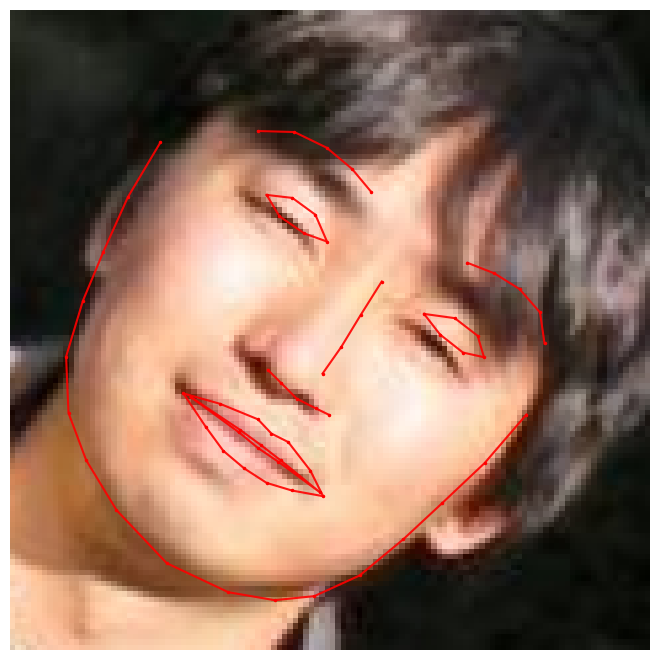

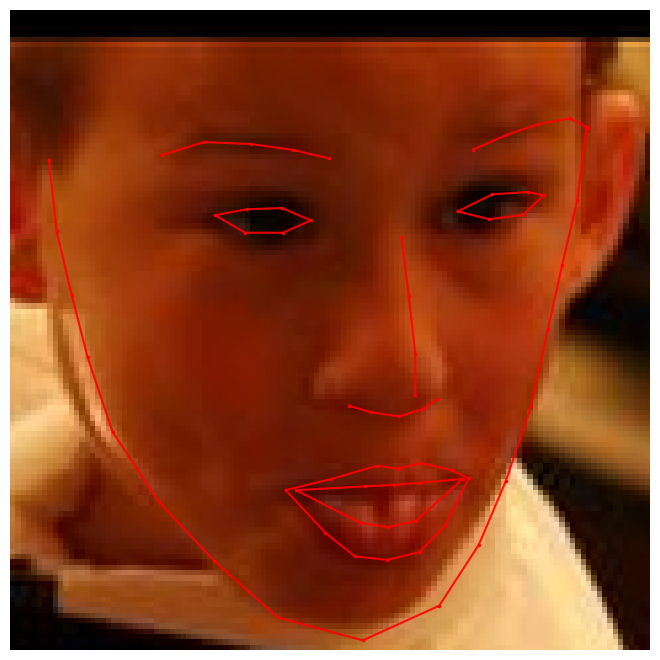

In [2]:
from pathlib import Path
import os.path as osp

root='/Users/saptarshimallikthakur/Pictures/VLM/Synergynet/train_aug_120x120'
filelists='/Users/saptarshimallikthakur/Pictures/VLM/Synergynet/3dmm_data/train_aug_120x120.list.train'
lines = Path(filelists).read_text().strip().split('\n')

pth = osp.join(root, lines[560200])
plot_face_landmarks(path=pth,
     model=tmodel,
     crop_face=True,
     alpha=1, markersize = 1.5, lw = 1.5)

pth = osp.join(root, lines[540301])
plot_face_landmarks(path=pth,
     model=tmodel,
     crop_face=True,
     alpha=1, markersize = 1.5, lw = 1.5)

cpu times =  0:00:00.083544


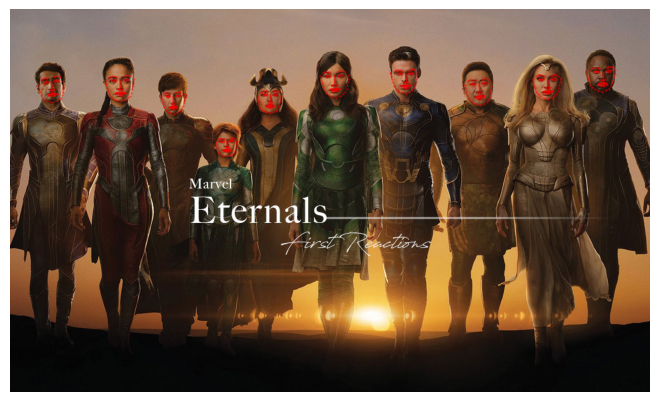

In [2]:
plot_face_landmarks(path='/Users/saptarshimallikthakur/Downloads/sample_1.jpg',
                    model=tmodel)

| Axis               | Meaning                                   | Rotation Direction                                                           |
| ------------------ | ----------------------------------------- | ---------------------------------------------------------------------------- |
| **Yaw (Y-axis)**   | Head turning left/right          | +ve → turn **right**, −ve → turn **left**                                    |
| **Pitch (X-axis)** | Head nodding up/down              | +ve → **downward**, −ve → **upward**                                         |
| **Roll (Z-axis)**  | Head tilting sideways (“Ear to shoulder”) | +ve → **clockwise tilt** (from viewer’s perspective), −ve → counterclockwise |


cpu times =  0:00:00.014532
(62,)
[-1.3701874635603726, -4.769717758929741, 38.6295206475686] [ 65.79434448  57.96354149 -96.6381264 ]


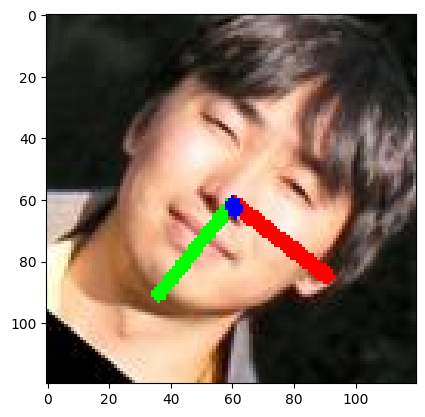

cpu times =  0:00:00.012434
(62,)
[-13.419955946965496, -21.23447098872416, 2.96815993896718] [ 56.87962529  76.23431305 -82.86240977]


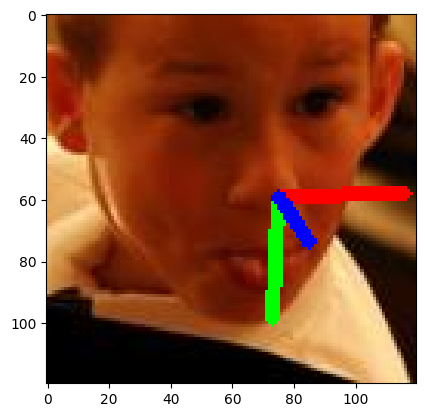

In [3]:
pth = osp.join(root, lines[560200])
plot_face_orientation(path=pth, 
                      model=tmodel)

pth = osp.join(root, lines[540301])
plot_face_orientation(path=pth, 
                      model=tmodel)

cpu times =  0:00:00.075620


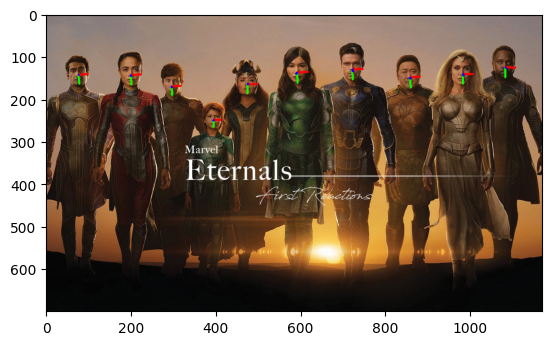

In [4]:
plot_face_orientation(path='/Users/saptarshimallikthakur/Downloads/sample_1.jpg', 
                      model=tmodel)

# BENCHMARK

In [5]:
from benchmark import *

benchmark()

Extracting params take  12.918s

Facial Alignment on AFLW2000-3D (NME):
[ 0, 30]	Mean: 3.254, Std: 1.479
[30, 60]	Mean: 4.152, Std: 1.986
[60, 90]	Mean: 5.416, Std: 2.231
[ 0, 90]	Mean: 4.274, Std: 0.887

Face orientation estimation:
Mean MAE = 4.404 (in deg), [yaw,pitch,roll] = [3.983, 5.251, 3.980]
